# RAGWire Setup and First Retrieval

**Stack:** Ollama · Qdrant (local)

Progressive journey:
- Ingest a single document and retrieve chunks
- Scale to multiple companies
- Explore metadata and add filters
- Build an agent — simple first, then filter-aware

## 1. Setup

In [8]:
from dotenv import load_dotenv
load_dotenv()

from ragwire import RAGWire, setup_logging
import ragwire

print(ragwire.__version__)


1.2.8


In [9]:
logger = setup_logging(log_level="INFO")

## 2. Ingest a Single Document and Retrieve

**Model:** `qwen3.5:9b` · **Embedding:** `qwen3-embedding:0.6b` · **Vector Store:** Qdrant (local)

In [51]:
rag = RAGWire('config.yaml')

2026-05-13 21:18:03,296 - ragwire.core.pipeline - INFO - Loading configuration from config.yaml
2026-05-13 21:18:03,517 - ragwire.core.pipeline - INFO - Document loader initialized
2026-05-13 21:18:03,519 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-05-13 21:18:04,043 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=ollama)
2026-05-13 21:18:04,510 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-05-13 21:18:04,511 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=ollama, model=qwen3.5:9b)
2026-05-13 21:18:04,857 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333
2026-05-13 21:18:05,010 - ragwire.vectorstores.qdrant_store - INFO - Deleted collection: finance-rag-ollama
2026-05-13 21:18:05,012 - ragwire.core.pipeline - INFO - Deleted existing collection for recreation: finance-rag-ollama
2026-05-1

In [14]:
stats = rag.ingest_documents(["../data/finance_data/Apple_10k_2025.pdf"])

2026-05-13 19:46:58,390 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-05-13 19:47:33,267 - ragwire.core.pipeline - WARNING - LLM metadata extraction failed for Apple_10k_2025.pdf: model requires more system memory (5.4 GiB) than is available (3.7 GiB) (status code: 500)
2026-05-13 19:50:47,340 - ragwire.core.pipeline - INFO - Processed ../data/finance_data/Apple_10k_2025.pdf: 35 chunks


Ingesting: 100%|██████████| 1/1 [03:48<00:00, 228.95s/file]


2026-05-13 19:50:48,966 - ragwire.core.pipeline - INFO - Ingestion complete: 1/1 documents


In [15]:
stats = rag.ingest_documents(["../data/finance_data/Apple_10k_2025.pdf"])

2026-05-13 19:50:49,002 - ragwire.core.pipeline - INFO - Starting ingestion of 1 documents


Ingesting:   0%|          | 0/1 [00:00<?, ?file/s]

2026-05-13 19:50:49,053 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf


Ingesting: 100%|██████████| 1/1 [00:00<00:00, 21.49file/s]


2026-05-13 19:50:49,346 - ragwire.core.pipeline - INFO - Ingestion complete: 0/1 documents


In [16]:
results = rag.retrieve("What is the apple's revenue?")

2026-05-13 19:50:49,655 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: What is the apple's revenue?...


In [17]:
results

[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_16', 'chunk_hash': '60b8d552baec48866282206f62d1d54dad52bc158891d1dcf5f9849c24cf4082', 'chunk_index': 16, 'total_chunks': 35, 'created_at': '2026-05-13T14:17:33.269957+00:00', '_id': '1cf42597-b555-4d82-864d-d1c5947e174d', '_collection_name': 'finance-rag-ollama'}, page_content='Earnings per share:\n\nBasic\nDiluted\n\nShares used in computing earnings per share:\n\nBasic\n\nDiluted\n\nSeptember 27,\n2025\n\nYears ended\n\nSeptember 28,\n2024\n\nSeptember 30,\n2023\n\n$\n\n$\n\n$\n$\n\n307,003  $\n109,158\n\n416,161\n\n294,866  $\n96,169\n\n391,035\n\n194,116\n26,844\n\n220,960\n\n195,201\n\n34,550\n27,601\n62,151\n\n185,233\n25,119\n\n210,352\n\n180,683\n\n31,370\n26,097\n57,467\n\n133,050\n(321)\n132,7

# RAGWire and Agentic RAG
- Upload set of documents
- Retrieval 
- Agentic RAG

## 3. Scale to Multiple Companies

Ingest all three 10-K filings at once. RAGWire deduplicates — re-running skips already-ingested files.

In [18]:
rag.ingest_directory('../data/finance_data')

2026-05-13 19:50:49,742 - ragwire.core.pipeline - INFO - Found 6 file(s) in ../data/finance_data
2026-05-13 19:50:49,746 - ragwire.core.pipeline - INFO - Starting ingestion of 6 documents


Ingesting:   0%|          | 0/6 [00:00<?, ?file/s]

2026-05-13 19:51:51,390 - ragwire.core.pipeline - WARNING - LLM metadata extraction failed for amazon 10-k 2024.pdf: model requires more system memory (5.4 GiB) than is available (4.4 GiB) (status code: 500)
2026-05-13 19:54:54,316 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10-k 2024.pdf: 39 chunks


Ingesting:  17%|█▋        | 1/6 [04:04<20:22, 244.57s/file]

2026-05-13 19:55:45,727 - ragwire.core.pipeline - WARNING - LLM metadata extraction failed for amazon 10k 2025.pdf: model requires more system memory (5.4 GiB) than is available (4.3 GiB) (status code: 500)
2026-05-13 19:58:45,026 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\amazon 10k 2025.pdf: 38 chunks


...

Ingesting:  83%|████████▎ | 5/6 [18:20<03:34, 214.66s/file]

2026-05-13 20:10:12,117 - ragwire.core.pipeline - WARNING - LLM metadata extraction failed for google 10-k 2024.pdf: model requires more system memory (5.4 GiB) than is available (4.3 GiB) (status code: 500)
2026-05-13 20:14:30,531 - ragwire.core.pipeline - INFO - Processed ..\data\finance_data\google 10-k 2024.pdf: 49 chunks


Ingesting: 100%|██████████| 6/6 [23:40<00:00, 236.80s/file]


2026-05-13 20:14:30,936 - ragwire.core.pipeline - INFO - Ingestion complete: 5/6 documents


{'total': 6,
 'processed': 5,
 'skipped': 1,
 'failed': 0,
 'chunks_created': 225,
 'errors': []}

## 4. Explore Metadata

RAGWire extracts company name, doc type, and fiscal year during ingestion. Let's inspect what's stored.

In [19]:
rag.discover_metadata_fields()

['source',
 'file_name',
 'file_type',
 'file_hash',
 'chunk_id',
 'chunk_hash',
 'chunk_index',
 'total_chunks',
 'created_at']

In [20]:
rag.filter_fields

['company_name', 'doc_type', 'fiscal_year', 'fiscal_quarter']

## 5. Manual Metadata Filters

The simple agent above can mix up companies when all three are in the same collection.
Filters let us pin retrieval to a specific company, year, or doc type.

In [21]:
query = "what is apple's revenue in 2025?"
results = rag.retrieve(query=query)

2026-05-13 20:14:31,425 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


In [22]:
results

[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_17', 'chunk_hash': '6f8d154ee3123334dcf4f277a15aaf1d235ed46a0a4fa4a3adcf44b3ade8c2b6', 'chunk_index': 17, 'total_chunks': 35, 'created_at': '2026-05-13T14:17:33.270003+00:00', '_id': '43eceb81-592e-42f2-a2aa-39fc6562bfeb', '_collection_name': 'finance-rag-ollama'}, page_content='Recently Adopted Accounting Pronouncements\n\nSegment Reporting\n\nBeginning  with  the  2025  annual  reporting  period,  the  Company  adopted  the  FASB’s  ASU  No.  2023-07,  Segment  Reporting  (Topic  280):  Improvements  to\nReportable Segment Disclosures (“ASU 2023-07”), which requires the Company to disclose segment expenses that are significant and regularly provided to the\nCompany’s chief operating decision maker (“CO

In [23]:
results = rag.retrieve(query=query, filters={'company_name':'apple inc.'})
results

2026-05-13 20:14:31,604 - ragwire.core.pipeline - INFO - Retrieved 0 documents for query: what is apple's revenue in 2025?...


[]

In [24]:
query = 'what is revenue on Google?'
results = rag.retrieve(query=query, filters={'company_name':'alphabet inc.'})
results

2026-05-13 20:14:31,757 - ragwire.core.pipeline - INFO - Retrieved 0 documents for query: what is revenue on Google?...


[]

In [25]:
query = 'what is revenue of Google in 2024?'
results = rag.retrieve(query=query, filters={'company_name':'alphabet inc.', 'fiscal_year': 2024})
results

2026-05-13 20:14:31,914 - ragwire.core.pipeline - INFO - Retrieved 0 documents for query: what is revenue of Google in 2024?...


[]

## 6. Auto-Filter

RAGWire can extract filters from the query automatically — no need to pass them manually.

In [26]:
rag._auto_filter

False

In [27]:
rag._auto_filter = True

In [28]:
query = "what is apple's revenue in 2025?"
results = rag.retrieve(query=query)
results

2026-05-13 20:14:37,897 - ragwire.core.pipeline - WARNING - Auto filter extraction failed: model requires more system memory (5.4 GiB) than is available (4.3 GiB) (status code: 500)
2026-05-13 20:14:42,815 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2025?...


[Document(metadata={'source': '../data/finance_data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_17', 'chunk_hash': '6f8d154ee3123334dcf4f277a15aaf1d235ed46a0a4fa4a3adcf44b3ade8c2b6', 'chunk_index': 17, 'total_chunks': 35, 'created_at': '2026-05-13T14:17:33.270003+00:00', '_id': '43eceb81-592e-42f2-a2aa-39fc6562bfeb', '_collection_name': 'finance-rag-ollama'}, page_content='Recently Adopted Accounting Pronouncements\n\nSegment Reporting\n\nBeginning  with  the  2025  annual  reporting  period,  the  Company  adopted  the  FASB’s  ASU  No.  2023-07,  Segment  Reporting  (Topic  280):  Improvements  to\nReportable Segment Disclosures (“ASU 2023-07”), which requires the Company to disclose segment expenses that are significant and regularly provided to the\nCompany’s chief operating decision maker (“CO

In [29]:
query = "what is apple's revenue in 2024?"
results = rag.retrieve(query=query)
results

2026-05-13 20:14:46,234 - ragwire.core.pipeline - WARNING - Auto filter extraction failed: model requires more system memory (5.4 GiB) than is available (3.7 GiB) (status code: 500)
2026-05-13 20:14:48,372 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: what is apple's revenue in 2024?...


[Document(metadata={'source': '..\\data\\finance_data\\apple 10-k 2024.pdf', 'file_name': 'apple 10-k 2024.pdf', 'file_type': 'pdf', 'file_hash': 'ec74758cd767465362c641cf2fd5d8fedd477aed2bf7f62117e67610435dcb88', 'chunk_id': 'ec74758cd767465362c641cf2fd5d8fedd477aed2bf7f62117e67610435dcb88_13', 'chunk_hash': '00f6e53c10e765bee12626b0deb0d6cae524339588cae41bef48d6b95a13d96f', 'chunk_index': 13, 'total_chunks': 53, 'created_at': '2026-05-13T14:29:31.473712+00:00', '_id': '6ebc22cc-c79b-4b48-beb1-62413ec0af6b', '_collection_name': 'finance-rag-ollama'}, page_content='Item 4.    Mine Safety Disclosures\n\nNot applicable.\n\nApple Inc. | 2024 Form 10-K | 18\n\n\x0cPART II\n\nItem 5.    Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities\n\nThe Company’s common stock is traded on The Nasdaq Stock Market LLC under the symbol AAPL.\n\nHolders\n\nAs of October 18, 2024, there were 23,301 shareholders of record.\n\nPurchases of Equity Sec

In [30]:
rag._auto_filter = False

## 7. Simple Agent — No Filters

Start with a basic agent that has one tool: `search_documents`. No metadata awareness yet.

In [45]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver

In [46]:
@tool
def search_documents(query: str):
    """Search the document knowledge base for relevant information."""

    results = rag.retrieve(query=query)

    if not results:
        return "No relevant information is found!"
    else:
        return results 


In [47]:
agent = create_agent(
    model=ChatOllama(model='qwen2.5:1.5b'),
    tools=[search_documents],
    system_prompt="You are a helpful document assistant. Use search_documents to answer questions.",
    checkpointer=InMemorySaver()
    )

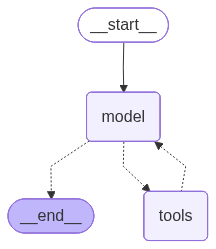

In [48]:
agent

In [49]:
config = {"configurable": {"thread_id": "session-1"}}

response = agent.invoke(
    {"messages": [HumanMessage("What is Apple's total revenue?")]},
    config=config,
)

In [ ]:
print(response["messages"][-1].text)

Based on Apple's financial documents:

**Apple's Total Revenue by Fiscal Year:**

- **Fiscal Year 2025** (ended September 27, 2025): **$416.161 billion**
- **Fiscal Year 2024** (ended September 28, 2024): **$391.035 billion**
- **Fiscal Year 2023** (ended September 30, 2023): **$383.285 billion**
- **Fiscal Year 2022** (ended September 24, 2022): **$394.328 billion**

Apple's total revenue has been growing steadily in recent fiscal years, with a notable increase in 2025 compared to previous years.

Would you like more detailed information about Apple's revenue breakdown by segment or category?


In [50]:
response = agent.invoke(
    {"messages": [HumanMessage("What is Apple's and googles total revenue in 2020?")]},
    config=config,
)

2026-05-13 21:16:18,147 - ragwire.core.pipeline - INFO - Retrieved 0 documents for query: Apple and Google total revenue 2020...


In [52]:
print(response["messages"][-1].text)

I'm sorry, but there was no document in our knowledge base that contains specific data on Apple's and Google's total revenues for 2020. For precise financial details like revenue figures, it would be best to refer directly to their official annual reports or to a reliable financial news source such as Bloomberg, Reuters, or the SEC filings.

If you have another period you're interested in, I can search that way instead. Let me know if there's anything else I can help with!


## 8. Filter-Aware Agent

Upgrade the agent with two tools: `get_filter_context` (inspect what's stored) and `search_documents` (retrieve with optional filters).
The model decides when to use filters based on the query.

We also upgrade the model to `qwen3.5:27b` for better multi-document reasoning.

In [53]:
query = "what is apple's revenue in 2025?"
filter_context = rag.get_filter_context(query=query)

2026-05-13 23:10:53,053 - ragwire.core.pipeline - WARNING - Auto filter extraction failed: model requires more system memory (5.4 GiB) than is available (1.2 GiB) (status code: 500)


In [54]:
print(filter_context)

## RAGWire Filter Context

### Available Metadata Fields and Stored Values
- **company_name**: []
- **doc_type**: []
- **fiscal_year**: []
- **fiscal_quarter**: []

### Extracted Filters from Query
- *(no filters extracted)*

### Instructions
1. Review the extracted filters above.
2. If an extracted value does not match or closely relate to any stored value, adjust or drop that filter.
3. If the query has no clear metadata intent, pass an empty dict `{}` as filters.
4. Pass the final filters dict to the retrieval tool as `filters=`.


In [55]:
@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)

In [57]:
@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 

In [60]:
agent = create_agent(
    # model=ChatOllama(model="qwen3.5:27b"),
    model=ChatOllama(model="qwen2.5:1.5b"),
    tools=[get_filter_context, search_documents],
    system_prompt=(
        "You are a helpful financial document assistant. "
        "For complex questions, break them down into simple sub-questions. "
        "Always use search_documents to retrieve information — never answer from general knowledge. "
        "Use get_filter_context before search_documents when the query involves specific metadata. "
        "Always cite the source document in your answer."
    ),
    checkpointer=InMemorySaver(),
)

## 9. Interactive Q&A Loop

Put it all together — the filter-aware agent in a conversational loop.

In [ ]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].content}\n")


RAG Agent ready. Type 'quit' to exit.

